from google.colab import drive
drive.mount('/content/drive')am

!cp  -r /content/drive/MyDrive/Colab_Notebooks/data/images/image_train /content
print("Ok!")
print("nombre d'images :")
!find /content/image_train/ -name '*.jpg' | wc -l

!python --version
!find /content/image_train/ -name '*.jpg' | wc -l

In [1]:
# Ajout du répertoire source au chemin Python pour pouvoir importer les modules locaux du projet
import sys
sys.path.append('../src')


In [2]:
# Lecture du fichier de configuration INI du projet pour récupérer les chemins des dossiers
# (dossier racine, dossier des images, dossier de sauvegarde des fichiers intermédiaires)
import configparser
config = configparser.ConfigParser()
config.read('../Rakuten_config2.ini')

# Fonctions utilitaires pour accéder aux chemins configurés
def get_RACINE_DOSSIER() :
    return config['DOSSIER']['RACINE_DOSSIER']
def get_RACINE_IMAGES() :
    return config['DOSSIER']['RACINE_IMAGES']
def get_RACINE_FICHIERS() :
    return config['DOSSIER']['RACINE_SAUVEGARDE']      

# Vérification : affichage des chemins lus depuis la config
print( get_RACINE_DOSSIER())   
print( get_RACINE_IMAGES())   


../input/
../data/images/image_train/


In [3]:
# Import des bibliothèques nécessaires au traitement et à l'analyse des images
import numpy as np                                    # Calculs numériques et tableaux
import pandas as pd                                   # Manipulation des données tabulaires
from sklearn.feature_extraction.text import CountVectorizer  # Vectorisation (non utilisé ici)
import matplotlib.pyplot as plt                       # Visualisation des images et graphiques
import os                                             # Gestion des chemins de fichiers
import cv2                                            # Traitement d'images (OpenCV)


In [4]:
# --- Chargement des données d'entraînement Rakuten ---

# Lecture des features (description produit, identifiants image et produit)
df_feats = pd.read_csv(get_RACINE_DOSSIER() + 'X_train_update.csv')

# Lecture des labels (codes de catégorie produit cibles)
df_target = pd.read_csv(get_RACINE_DOSSIER() + 'Y_train_CVw08PX.csv')

# Fusion des deux dataframes sur l'identifiant commun pour former un dataframe complet
df = df_feats.merge(df_target, on='Unnamed: 0', how='inner')
df.rename(columns={'Unnamed: 0': 'Id'}, inplace=True)

# Récupération de la liste des catégories produit uniques (triées)
cat = df_target['prdtypecode'].sort_values().unique()
cat

# Chargement du fichier de nomenclature pour associer chaque code catégorie à sa définition textuelle
nomenclature = pd.read_csv(get_RACINE_DOSSIER() + 'NOMENCLATURE.csv', header=0, encoding='utf-8', sep=';', index_col=0)
catdict = nomenclature.to_dict()['definition']


In [5]:
df_feats.head(5)

,Unnamed: 0,designation,description,productid,imageid
0,0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786


In [6]:
df_target.head(5)

,Unnamed: 0,prdtypecode
0,0,10
1,1,2280
2,2,50
3,3,1280
4,4,2705


In [7]:
# Construction du nom de fichier image pour chaque produit (format : image_<imageid>_product_<productid>.jpg)
# Cette colonne permet de localiser le fichier image sur le disque
df['nom_image'] = df.apply(lambda row: "image_" + str(row['imageid']) 
                                      + "_product_" + str(row['productid']) + ".jpg", axis=1)
print("Nb enreg ", str(df.shape[0]))
df.head(5)

# Copie du dataframe pour les traitements suivants (préserve le dataframe original)
df_img = df.copy()


Nb enreg  84916


### test de lecture d'images


--- Catégorie 40 (jeux video pour pc et consoles) ---


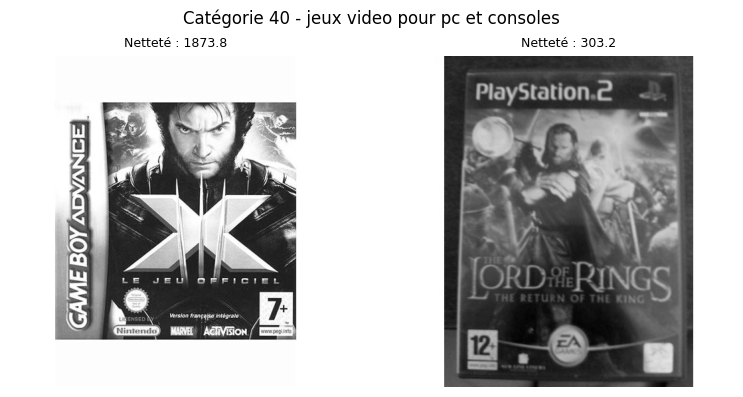


--- Catégorie 50 ( accesoires jeux video) ---


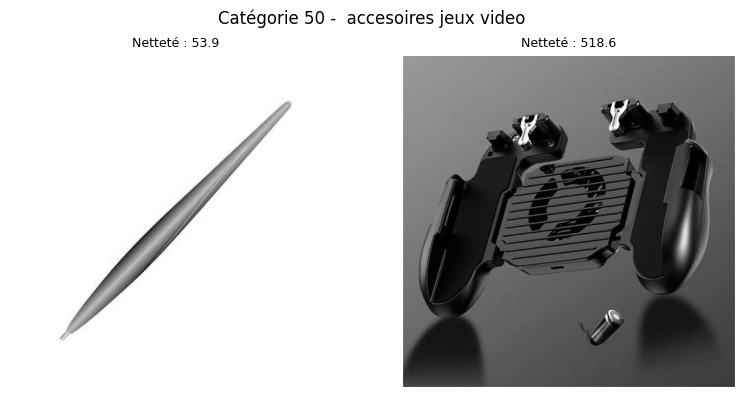


--- Catégorie 60 (consoles de jeux video) ---


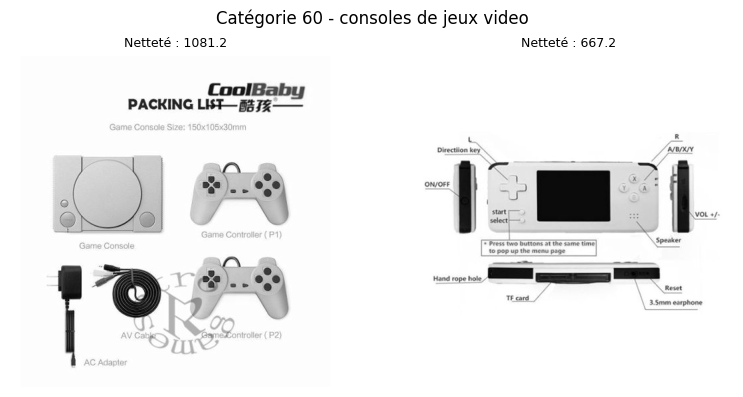


--- Catégorie 1280 (jouets, peluches, poupees) ---


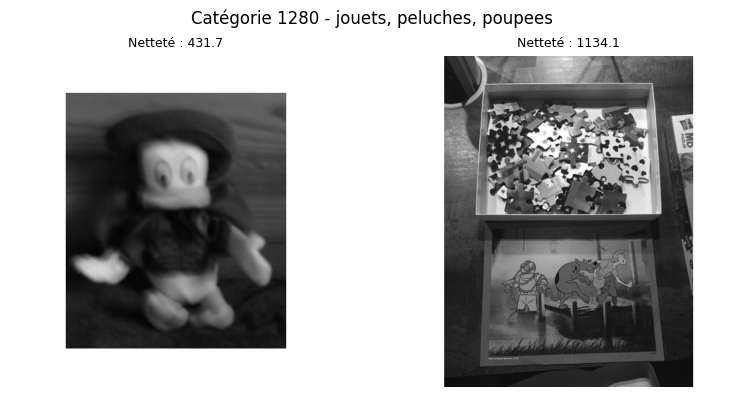


Nombre d'images chargées (catégorie 1280) : 4870
Dimensions du tableau : (4870, 500, 500)


In [8]:
import os
import cv2
import numpy as np
from PIL import Image

# --- Mesure de la netteté des images ---
# La netteté est estimée via la variance du Laplacien :
# plus la variance est élevée, plus l'image est nette.
# Un score faible indique une image floue.
def measure_sharpness(image):
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    return np.var(laplacian)

# Chemin du dossier contenant les images d'entraînement
folder_path = get_RACINE_IMAGES()

# Catégories à analyser
categories = [40, 50, 60, 1280]

# Filtrage des données sur le sous-ensemble de catégories
df_img = df[df['prdtypecode'].isin(categories)]

# Affichage de 2 images par catégorie avec leur score de netteté
NB_IMAGES_PAR_CATEGORIE = 2

for c in categories:
    print(f"\n--- Catégorie {c} ({catdict.get(c, '')}) ---")
    filenames = df_img['nom_image'][df_img['prdtypecode'] == c].tolist()
    count = 0
    fig, axs = plt.subplots(1, NB_IMAGES_PAR_CATEGORIE, figsize=(8, 4))
    fig.suptitle(f"Catégorie {c} - {catdict.get(c, '')}")
    for filename in filenames:
        if count >= NB_IMAGES_PAR_CATEGORIE:
            break
        img = cv2.imread(os.path.join(folder_path, filename))
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            sharpness = measure_sharpness(gray)
            axs[count].imshow(gray, cmap='gray')
            axs[count].set_title(f"Netteté : {sharpness:.1f}", fontsize=9)
            axs[count].axis('off')
            count += 1
    plt.tight_layout()
    plt.show()

# Chargement de toutes les images de la catégorie 1280 pour les traitements suivants
image_list = []
for filename in df_img['nom_image'][df_img['prdtypecode'] == 1280]:
    img = cv2.imread(os.path.join(folder_path, filename))
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        image_list.append(gray)

# Conversion de la liste en tableau numpy pour traitement vectorisé
images = np.array(image_list)
print(f"\nNombre d'images chargées (catégorie 1280) : {len(images)}")
print(f"Dimensions du tableau : {images.shape}")

# Référence vers la première image pour tests ponctuels
image = image_list[0]


In [9]:
# Redéfinition locale de la fonction de netteté (en cas d'exécution isolée de cette cellule)
# et calcul de la netteté de la première image chargée
def measure_sharpness(image):
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    return np.var(laplacian)

sharpness = measure_sharpness(image)
print('Sharpness:', sharpness)


Sharpness: 431.738072


(4870, 500, 500)


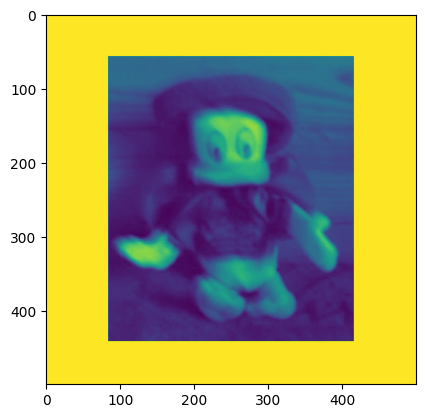

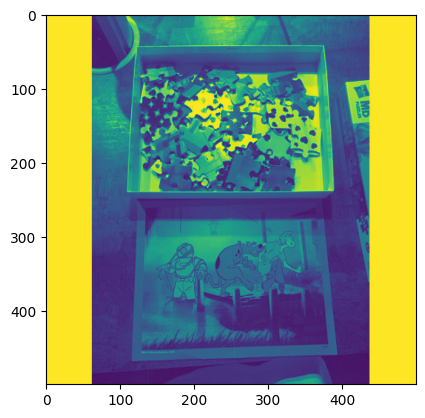

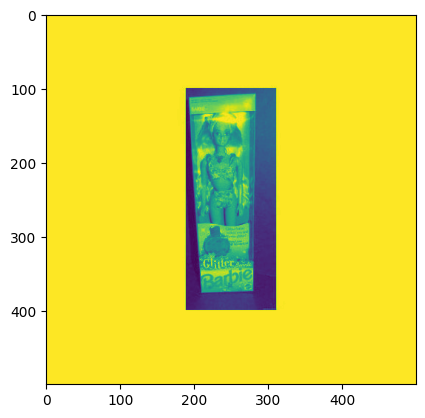

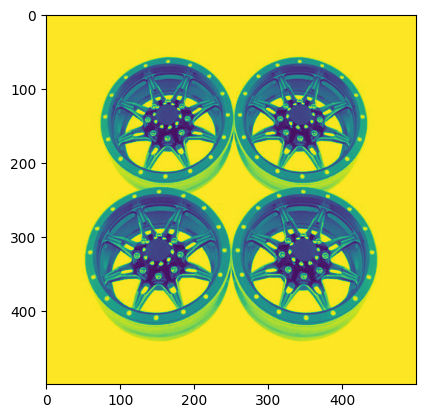

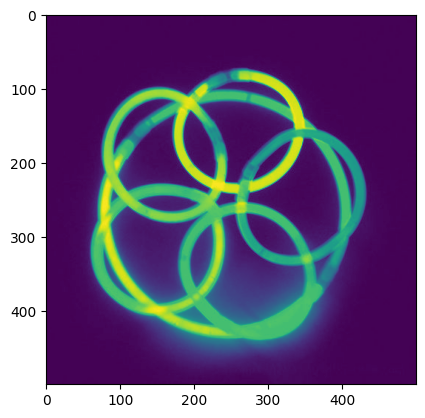

In [11]:
# Affichage des 9 premières images en niveaux de gris pour vérification visuelle du contenu
print(images.shape)
for i in range(5):
    image = images[i, :, :]
    plt.imshow(image)
    plt.show()


### test de contours et de formes (NB angles et de cercles)

In [12]:
# --- Analyse des contours et des formes géométriques (test sur catégorie 1280) ---
# Pour chaque image, on extrait deux descripteurs géométriques :
#   - corners   : nombre de sommets/angles du contour (triangle=3, rectangle=4, etc.)
#   - circularity : mesure à quel point la forme est circulaire (1 = cercle parfait)
# Ces descripteurs peuvent servir à caractériser visuellement les produits d'une catégorie.

Dfcontour = pd.DataFrame()

# Dictionnaire de référence des formes selon le nombre de sommets
classes = {0: 'cercle', 2: 'ligneE', 3: 'triangle', 4: 'rectangle', 5: 'pentagone', 6: 'hexagone'}

for i in range(len(images)):
    gray = images[i, :, :]
    # Réduction du bruit par flou gaussien avant détection des contours
    gray_blur = cv2.GaussianBlur(gray, (3, 3), 0)
    # Détection des contours avec l'algorithme de Canny (seuils bas=50, haut=150)
    edges = cv2.Canny(gray_blur, 50, 150, apertureSize=3)
    # Extraction des contours externes sous forme de polygones
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    shapes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        # Calcul de la circularité : ratio entre l'aire et le périmètre (formule isopérimétrique)
        if perimeter == 0:
            circularity = 0
        else:
            circularity = 4 * np.pi * area / perimeter ** 2
        # Approximation polygonale du contour pour compter le nombre de sommets
        approx = cv2.approxPolyDP(cnt, 0.01 * perimeter, True)
        corners = len(approx)
        shapes.append((corners, circularity))
    # Accumulation des résultats dans le DataFrame global
    if len(shapes) != 0:
        if len(Dfcontour) == 0:
            Dfcontour = pd.DataFrame(shapes, columns=['corners', 'circularity'])
        else:
            Dfcontour = pd.concat([Dfcontour, pd.DataFrame(shapes, columns=['corners', 'circularity'])],
                                  ignore_index=True, axis=0)
print(Dfcontour.head())


   corners  circularity
0        4     0.710107
1        8     0.007081
2        8     0.003265
3        7     0.013843
4       12     0.009002


In [13]:
# Vérification du contenu du DataFrame des contours : types, nombre de lignes, valeurs nulles
print(Dfcontour.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665191 entries, 0 to 665190
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   corners      665191 non-null  int64  
 1   circularity  665191 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 10.2 MB
None


## Dataframe des contours par catégorie

In [14]:
# --- Construction du DataFrame des contours pour TOUTES les catégories ---
# Pour chaque catégorie produit, on charge toutes ses images, puis on calcule
# les descripteurs géométriques de contours (nombre de sommets et circularité).
# Le code catégorie (prdtypecode) est ajouté comme colonne pour permettre l'analyse comparative.

df_img = df.copy()
Dfcontour = pd.DataFrame()

for c in cat:
    print("Catégorie : ", c, catdict[c])
    image_list = []
    # Chargement de toutes les images appartenant à la catégorie courante
    for filename in df_img[df_img['prdtypecode'] == c]['nom_image']:
        img = cv2.imread(os.path.join(folder_path, filename))
        if img is not None:
            image_list.append(img)
    images = np.array(image_list)

    # Analyse des contours de chaque image de la catégorie
    for i in range(len(images)):
        image = images[i, :, :, :]
        # Conversion en niveaux de gris
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Réduction du bruit par flou gaussien
        gray_blur = cv2.GaussianBlur(gray, (3, 3), 0)
        # Détection des contours avec Canny
        edges = cv2.Canny(gray_blur, 50, 150, apertureSize=3)
        # Extraction des contours externes
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        shapes = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            # Calcul de la circularité du contour
            if perimeter == 0:
                circularity = 0
            else:
                circularity = 4 * np.pi * area / perimeter ** 2
            # Nombre de sommets de l'approximation polygonale
            approx = cv2.approxPolyDP(cnt, 0.01 * perimeter, True)
            corners = len(approx)
            shapes.append((c, corners, circularity))
        # Accumulation dans le DataFrame global avec le code catégorie
        if len(shapes) != 0:
            if len(Dfcontour) == 0:
                Dfcontour = pd.DataFrame(shapes, columns=['prdtypecode', 'corners', 'circularity'])
            else:
                Dfcontour = pd.concat([Dfcontour, pd.DataFrame(shapes, columns=['prdtypecode', 'corners', 'circularity'])],
                                      ignore_index=True, axis=0)
print(Dfcontour.head())


Catégorie :  10 livres
Catégorie :  40 jeux video pour pc et consoles
Catégorie :  50  accesoires jeux video
Catégorie :  60 consoles de jeux video
Catégorie :  1140 produits derives “geeks” et figurines
Catégorie :  1160 cartes collectionables
Catégorie :  1180 figurines collectionables pour jeux de societe
Catégorie :  1280 jouets, peluches, poupees
Catégorie :  1281 jeux de societe/cartes
Catégorie :  1300 Petites voitures (jouets) et maquettes
Catégorie :  1301 accesoires pour petis enfants/bebes et mobilier de jeu (flechettes, billard, babyfoot)
Catégorie :  1302 jeux d'exterieur
Catégorie :  1320 sacs pour femmes et accesore petite enfance
Catégorie :  1560 Mobilier et produits decoration/rangement pour la maison
Catégorie :  1920 linge de maison (cousins, rideaux, serviettes, nappes, draps)
Catégorie :  1940 nouriture (cafes,infusions,conserves, epices,etc)
Catégorie :  2060 lampes et accesoires decoration pour maison
Catégorie :  2220 accesoires mascots/pets
Catégorie :  2280 m

In [15]:
# Sauvegarde du DataFrame des contours en CSV pour réutilisation ultérieure sans recalcul
Dfcontour.to_csv(get_RACINE_FICHIERS() + 'Dfcontour.csv')


In [16]:
# Rechargement du DataFrame des contours depuis le fichier CSV précédemment sauvegardé
Dfcontour = pd.read_csv(get_RACINE_FICHIERS() + 'Dfcontour.csv')


### Histogramme des angles toutes catagories confonfues

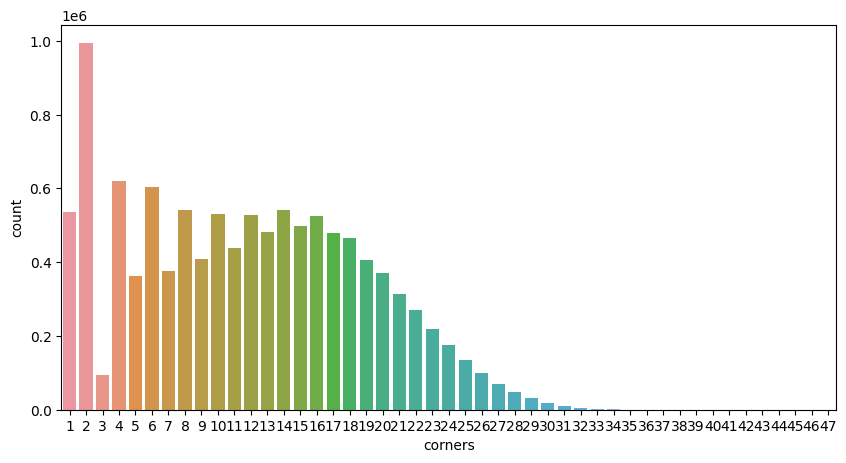

In [17]:
# Histogramme du nombre de sommets (corners) détectés dans les contours,
# toutes catégories confondues.
# Permet d'observer la distribution globale des formes géométriques présentes dans les images.
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
sns.countplot(x=Dfcontour['corners'])
plt.show()


In [ ]:
### Histogramme des circularités toutes catagories confonfues

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


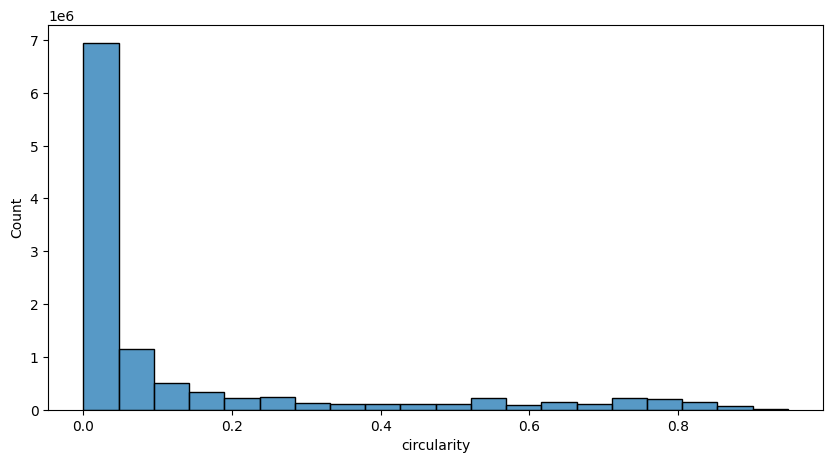

In [18]:
# Histogramme de la circularité des contours, toutes catégories confondues.
# Une valeur proche de 1 indique des formes très circulaires,
# une valeur proche de 0 indique des formes allongées ou irrégulières.
plt.figure(figsize=(10, 5))
sns.histplot(x=Dfcontour['circularity'], bins=20)
plt.show()


In [19]:
# Affichage du résumé du DataFrame des contours (types de colonnes, valeurs nulles, taille)
Dfcontour.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11198695 entries, 0 to 11198694
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Unnamed: 0   int64  
 1   prdtypecode  int64  
 2   corners      int64  
 3   circularity  float64
dtypes: float64(1), int64(3)
memory usage: 341.8 MB


In [20]:
# Rechargement du DataFrame et vérification de la répartition des contours par catégorie produit
Dfcontour = pd.read_csv(get_RACINE_FICHIERS() + 'Dfcontour.csv')
Dfcontour.info()
# Distribution du nombre de contours extraits par catégorie
Dfcontour['prdtypecode'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11198695 entries, 0 to 11198694
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Unnamed: 0   int64  
 1   prdtypecode  int64  
 2   corners      int64  
 3   circularity  float64
dtypes: float64(1), int64(3)
memory usage: 341.8 MB


prdtypecode
2583    999169
2403    993204
2280    982625
2060    880506
1920    677977
1280    665191
1300    587957
1160    587928
40      528314
10      461580
1560    454826
1281    329901
1320    327060
2522    326203
2582    314800
1140    295228
1302    292534
2585    263436
2705    259619
2462    226435
50      142427
2905    120274
2220    107414
1180    104411
1940    100290
60       95714
1301     73672
Name: count, dtype: int64

10 livres
40 jeux video pour pc et consoles
50  accesoires jeux video
60 consoles de jeux video
1140 produits derives “geeks” et figurines
1160 cartes collectionables
1180 figurines collectionables pour jeux de societe
1280 jouets, peluches, poupees
1281 jeux de societe/cartes
1300 Petites voitures (jouets) et maquettes
1301 accesoires pour petis enfants/bebes et mobilier de jeu (flechettes, billard, babyfoot)
1302 jeux d'exterieur
1320 sacs pour femmes et accesore petite enfance
1560 Mobilier et produits decoration/rangement pour la maison
1920 linge de maison (cousins, rideaux, serviettes, nappes, draps)
1940 nouriture (cafes,infusions,conserves, epices,etc)
2060 lampes et accesoires decoration pour maison
2220 accesoires mascots/pets
2280 magazines
2403 livres et bds
2462 consoles de jeux video et jeux videos
2522 produits de papeterie et rangement bureau
2582 mobilier d'exterieur et accesoires (parasols,pots,tentes,etc)
2583 accesoires de piscine
2585 outillage et accesoires pour j

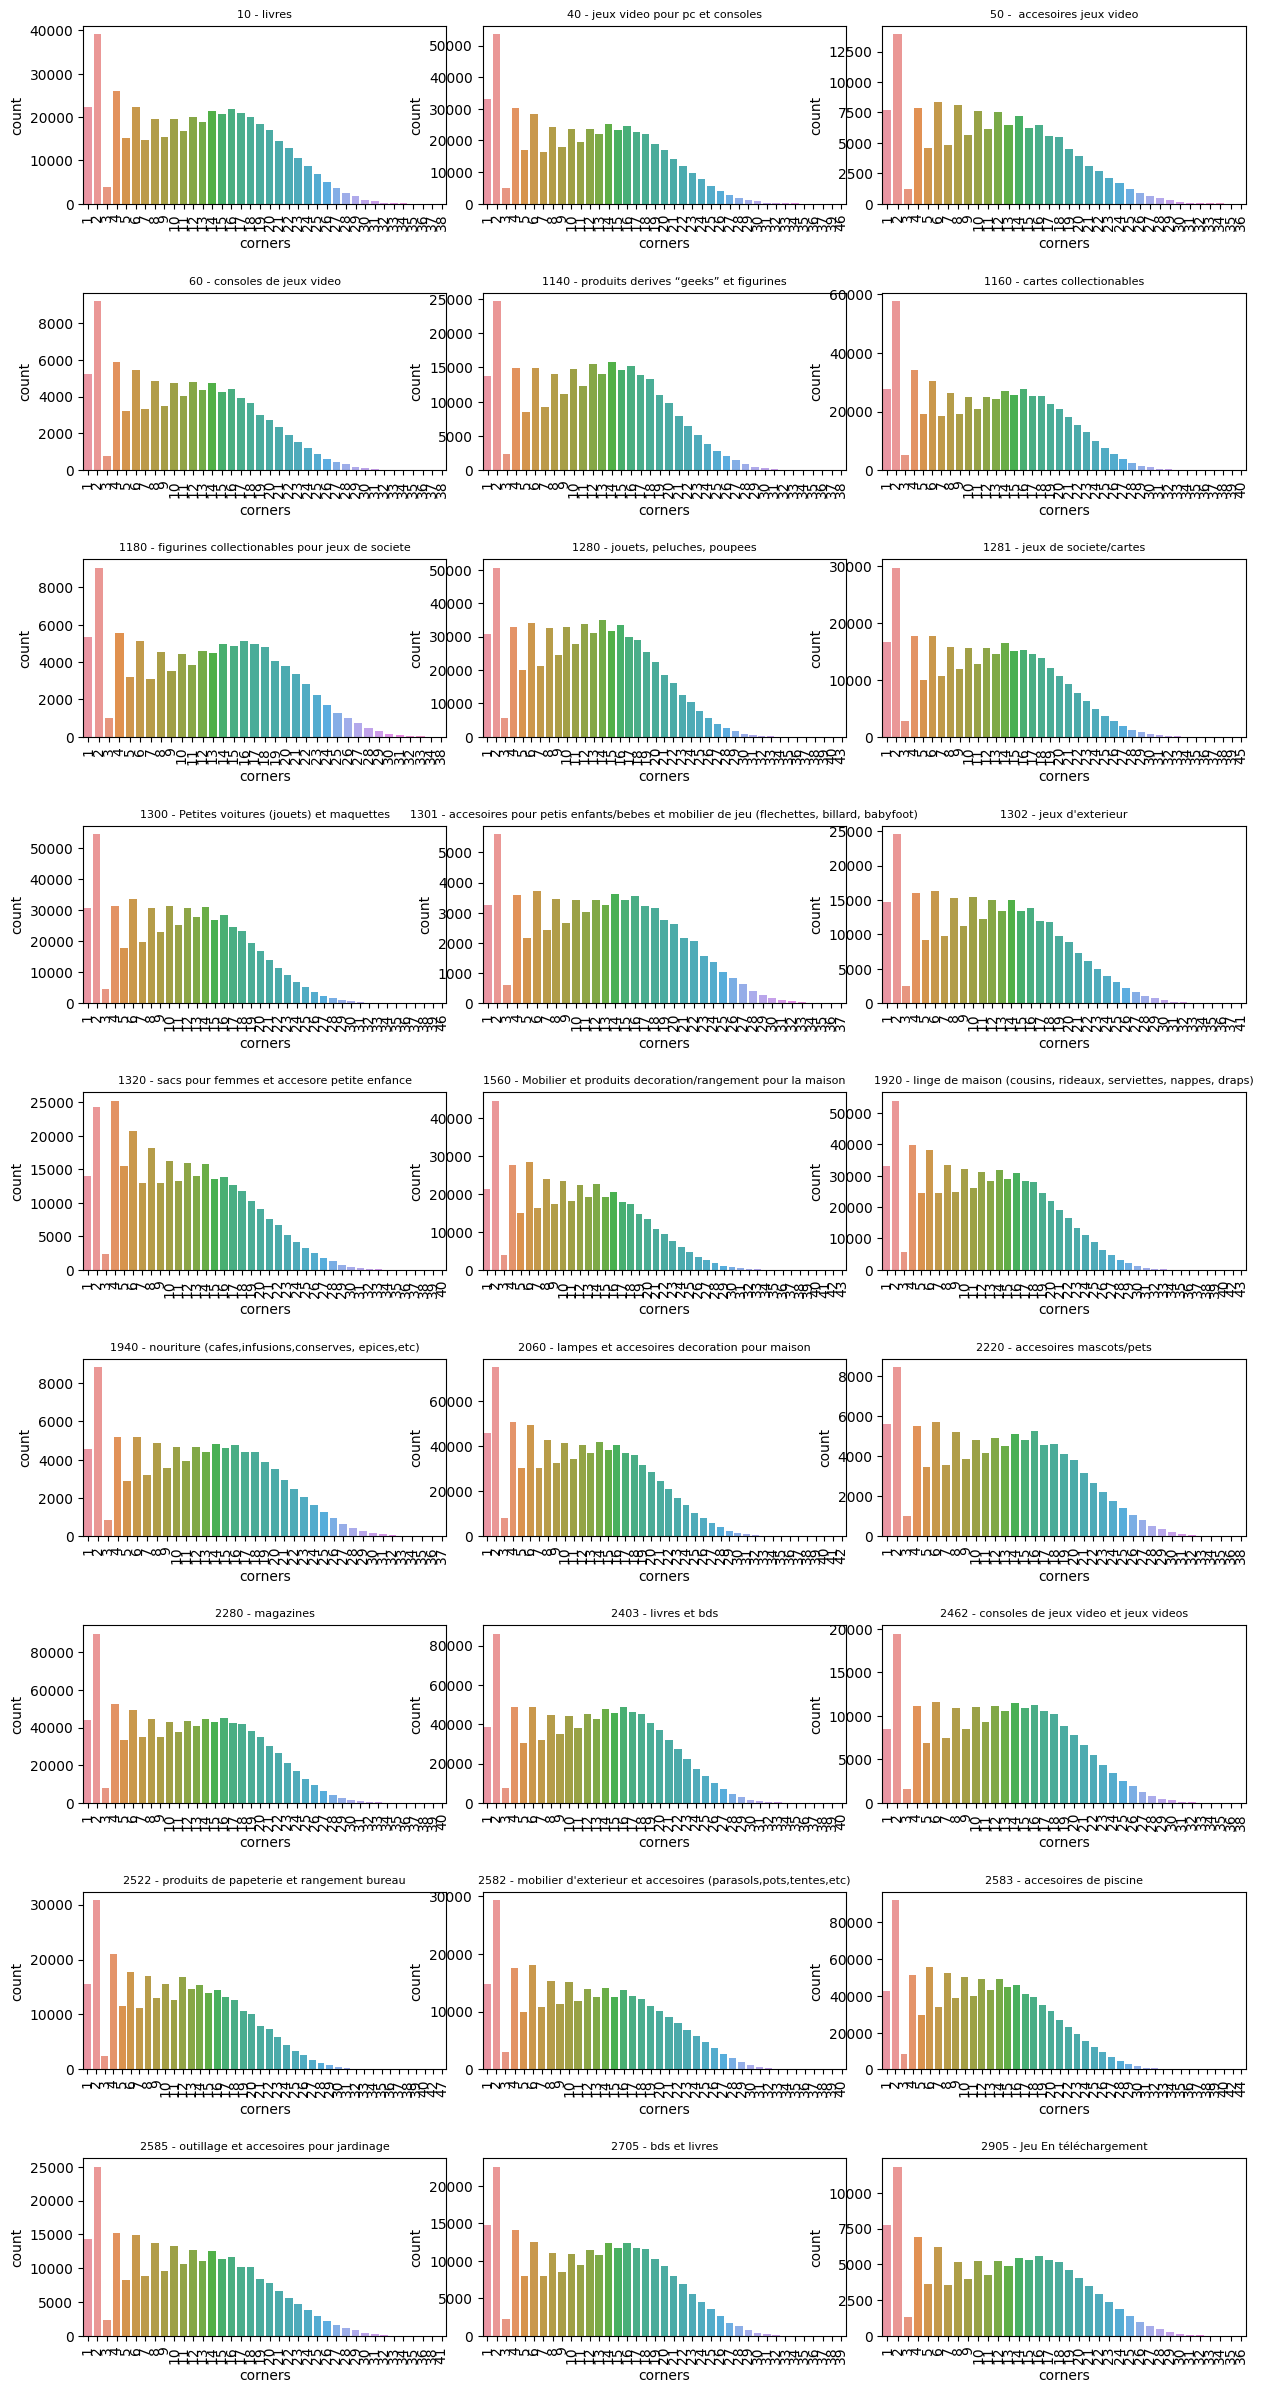

In [21]:
# Grille de graphiques (une sous-figure par catégorie) montrant la distribution
# du nombre de sommets (corners) des contours.
# Permet de comparer visuellement les profils de formes géométriques d'une catégorie à l'autre :
# certaines catégories peuvent avoir majoritairement des formes rectangulaires (packaging),
# d'autres des formes plus complexes ou circulaires (jouets, équipements...).
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(9, 3, figsize=(15, 30))
for c, ax in zip(cat, axs.flat):
    print(c, catdict[c])
    sns.countplot(x=Dfcontour[Dfcontour['prdtypecode'] == c]['corners'], ax=ax)
    ax.set_title(f"{c} - {catdict[c]}", fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.subplots_adjust(wspace=0.1, hspace=0.5)
plt.show()
